# Konfiguracja środowiska i pobieranie danych

W tej sekcji instalujemy niezbędne biblioteki oraz pobieramy dataset z Roboflow, znajdujący się pod linkiem: https://universe.roboflow.com/blackjack-jacob/blackjack-cards-bv2sh. Roboflow umożliwia przechowywanie, wersjonowanie i optymalizację zestawów danych obrazowych. W naszym projekcie służy jako centralne repozytorium, z którego pobieramy gotowe, wyetykietowane zdjęcia wraz z plikami konfiguracyjnymi YAML.

Dataset zawiera ponad 8 tysięcy zdjęć najróżniejszych typów kart w najróżniejszych konfiguracjach. Ma to zapewnić, że model będzie realizował zadanie nawet w niekomfortowych warunkach, uwzględniając karty wadliwe lub “zużyte”, częściowo zasłonięte oraz poprzesuwane. Dzięki tak bogatemu zasobowi datasetu nie ma konieczności dostarczania własnych zdjęć.

In [ ]:
!pip install -q roboflow ultralytics python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.0 MB/s eta 0:00:00


In [ ]:
from dotenv import load_dotenv
import os
from roboflow import Roboflow

load_dotenv()

roboflow_api_key = os.getenv("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=roboflow_api_key)
project = rf.workspace("blackjack-jacob").project("blackjack-cards-bv2sh")
version = project.version(1)

dataset = version.download("yolov8", location="/data")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /data in yolov8:: 100%|██████████| 40496/40496 [00:09<00:00, 4151.00it/s]


# Weryfikacja dostępności karty graficznej

Dostępność karty graficznej jest kluczowa dla szybkiego trenowania sieci neuronowych

In [ ]:
import torch
print(torch.cuda.is_available())

True


# Analiza i Weryfikacja Datasetu

Zgodnie z wymaganiami określonymi w kamieniach milowych, sprawdzamy jakość danych przed trenowaniem. Szukamy kart zasłoniętych i przesuniętych. Funkcja `plot_sample_images` wyświetla przykładowe zdjęcia\ z folderu treningowego.

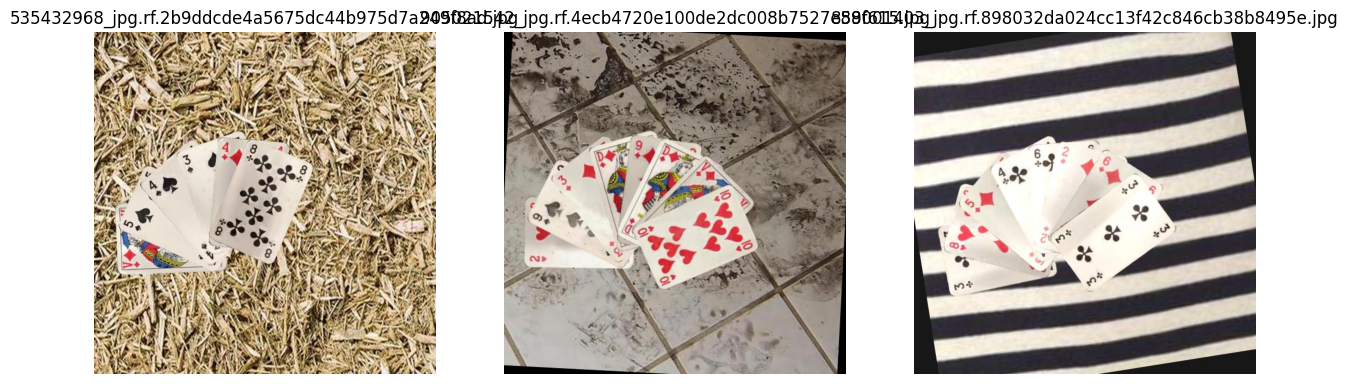

In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

def plot_sample_images(dataset_path, num_images=3):
    img_path_pattern = os.path.join(dataset_path, "train/images/*.*")
    all_images = glob.glob(img_path_pattern)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    images = [img for img in all_images if img.lower().endswith(valid_extensions)][:num_images]

    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path))
    plt.show()

plot_sample_images("/data")

# Trening modelu

Konfigurujemy proces uczenia. Dodajemy parametry augmentacji, aby uodpornić model na trudne warunki (cienie, rozmycia, rotacje).

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

model.train(
    data='/data/data.yaml',
    epochs=100,
    imgsz=320,
    batch=16,
    plots=True,
    device=0,
    workers=8,
    patience=5
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, 

# Wznowienie trenowania modelu

W przypadku tak długiego procesu uczenia (uczenie jednej epoki to czas około 3-4 minut, co przy 100 epokach daje ponad 6 godzin szkolenia modelu). Zachodzi więc konieczność, aby uwzględnić możliwość wznowienia procesu od ostatniego zapisanego punktu kontrolnego.

In [ ]:
from ultralytics import YOLO

path_to_last = 'runs/detect/train/weights/last.pt'

model = YOLO(path_to_last)
model.train(resume=True)

# Walidacja i Testowanie

Po zakończeniu uczenia dokonujemy oceny skuteczności modelu na odseparowanym zbiorze testowym, którego sieć nie widziała podczas treningu.

In [ ]:
from IPython.display import Image

Image(filename='runs/detect/train/train_batch0.jpg')
best_model = YOLO('runs/detect/train/weights/best.pt')
metrics = best_model.val(split='test')

print(f"Metryka mAP50 na zbiorze testowym: {metrics.box.map50}")